In [2]:
import torch
print("CUDA version PyTorch built with:", torch.version.cuda)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

CUDA version PyTorch built with: 12.1
cuDNN enabled: True


In [3]:
import torch
import cv2
import numpy as np
import torch.nn.functional as F
import sys
from torch.cuda.amp import autocast
sys.path.append(r"D:\13. AIC")

from transnetv2.inference_pytorch.transnetv2_pytorch import TransNetV2

# 1. Chọn device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

# 2. Khởi tạo model và load weights
model = TransNetV2().to(device)
state_dict = torch.load(
    r"D:\13. AIC\transnetv2\transnetv2-pytorch-weights.pth",
    map_location=device
)
model.load_state_dict(state_dict)
model.eval()

# 3. Đọc video và resize frame
cap = cv2.VideoCapture(r"D:\13. AIC\videos\videoplayback.webm")
frames = []
frames_original = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames_original.append(rgb)
    frames.append(cv2.resize(rgb, (48, 27)))
cap.release()

Running on: cuda


In [4]:
# 4. Chia nhỏ video thành các chunks và xử lý từng chunk
chunk_size = 100  # Số frame mỗi chunk, có thể điều chỉnh
predictions = []

for i in range(0, len(frames), chunk_size):
    chunk = frames[i:i + chunk_size]
    chunk_np = np.stack(chunk).astype(np.uint8)  # (chunk_size, 27, 48, 3)
    chunk_t = torch.from_numpy(chunk_np).unsqueeze(0).to(device)  # (1, chunk_size, 27, 48, 3)
    
    # 5. Chạy inference với mixed precision
    with torch.no_grad():
        with autocast():
            output = model(chunk_t)
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output
            probs = torch.sigmoid(logits.squeeze(0).squeeze(-1)).cpu().numpy()  # (chunk_size,)
    predictions.append(probs)

# 6. Ghép các dự đoán từ các chunks
single_frame_p = np.concatenate(predictions)
print("Output shape:", single_frame_p.shape)

c:\Users\LENOVO\anaconda3\envs\oai-hutech\Lib\site-packages\torch\nn\modules\conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv3d(


Output shape: (28295,)


In [20]:
import os
import numpy as np
import cv2

# --- HYPERPARAMS (tùy chỉnh) ---
smoothing_window = 5       # cửa sổ làm mượt (odd number)
frames_rgb = frames_original  # dùng frame gốc RGB đã lưu trước đó
out_dir = r"D:\13. AIC\selected_frames"  # nơi lưu frame chọn ra
os.makedirs(out_dir, exist_ok=True)

# --- 1. làm mượt xác suất bằng convolution 1D ---
k = np.ones(smoothing_window, dtype=float) / smoothing_window
probs_smooth = np.convolve(single_frame_p, k, mode='same')

In [21]:
threshold = float(probs_smooth.mean())  
auto_threshold = 0.5 * (np.mean(probs_smooth) + np.median(probs_smooth))

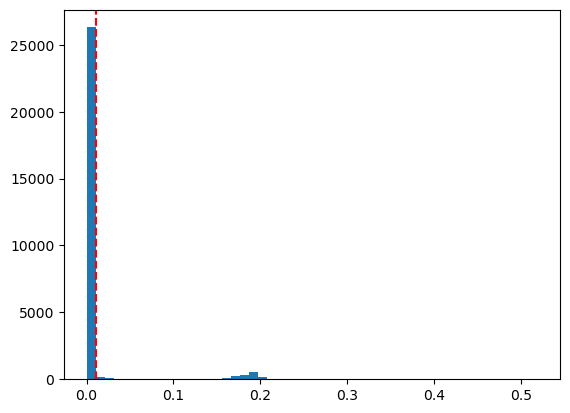

In [22]:
import matplotlib.pyplot as plt
plt.hist(probs_smooth, bins=50)
plt.axvline(threshold, color='r', linestyle='--')
plt.show()

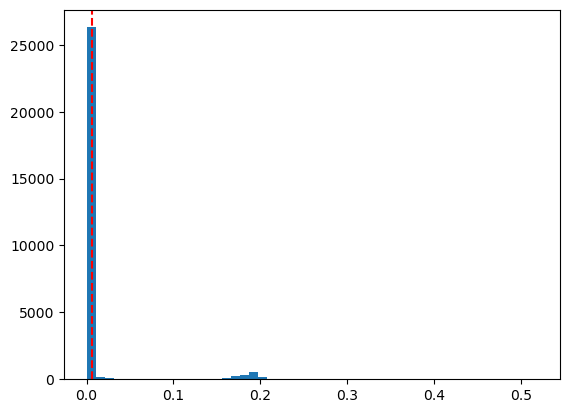

In [23]:
import matplotlib.pyplot as plt
plt.hist(probs_smooth, bins=50)
plt.axvline(auto_threshold, color='r', linestyle='--')
plt.show()

### Lưu ý:

Nếu đồ thị lệch trái thì dùng `out_threshold` nếu đều hoặc gần đều thì ưu tiên dùng `threshol`

In [ ]:
# --- 2. đánh dấu frame chuyển cảnh ---
is_transition = probs_smooth > auto_threshold  # Xem trên lưu ý!

# (tuỳ chọn) in một số thống kê nhanh
print(f"Total frames: {len(frames_rgb)}")
print(f"Total predicted transition frames (raw): {is_transition.sum()}")

# --- 3. tách scene: gom các frame không phải transition thành các segment ---
segments = []
current_segment = []
for idx, is_t in enumerate(is_transition):
    if not is_t:
        current_segment.append(idx)
    else:
        if current_segment:
            segments.append(current_segment)
            current_segment = []
# push cuối cùng nếu còn
if current_segment:
    segments.append(current_segment)

print(f"Detected {len(segments)} scenes (segments without transition frames).")

# --- 4. từ mỗi scene chọn tối đa 4 frame đều phân bố ---
selected_indices = []
for seg_id, seg in enumerate(segments):
    seg_len = len(seg)
    if seg_len == 0:
        continue
    n_pick = min(4, seg_len)
    # lấy chỉ số tương ứng trong seg (cách đều)
    picks = np.linspace(0, seg_len - 1, num=n_pick, dtype=int)
    chosen = [seg[i] for i in picks]
    selected_indices.extend(chosen)
    # (tuỳ chọn) in thông tin scene
    print(f"Scene {seg_id}: length={seg_len} -> pick {n_pick} frames at indices {chosen}")

# --- 5. lưu các frame đã chọn ---
for i, idx in enumerate(selected_indices):
    rgb = frames_rgb[idx]                 # RGB
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    fname = os.path.join(out_dir, f"frame_{idx:06d}.jpg")
    cv2.imwrite(fname, bgr)
print(f"Saved {len(selected_indices)} frames to {out_dir}")


Total frames: 28295
Total predicted transition frames (raw): 2378
Detected 420 scenes (segments without transition frames).
Scene 0: length=48 -> pick 4 frames at indices [0, 15, 31, 47]
Scene 1: length=22 -> pick 4 frames at indices [76, 83, 90, 97]
Scene 2: length=19 -> pick 4 frames at indices [123, 129, 135, 141]
Scene 3: length=49 -> pick 4 frames at indices [158, 174, 190, 206]
Scene 4: length=4 -> pick 4 frames at indices [218, 219, 220, 221]
Scene 5: length=51 -> pick 4 frames at indices [238, 254, 271, 288]
Scene 6: length=6 -> pick 4 frames at indices [303, 304, 306, 308]
Scene 7: length=27 -> pick 4 frames at indices [327, 335, 344, 353]
Scene 8: length=27 -> pick 4 frames at indices [357, 365, 374, 383]
Scene 9: length=7 -> pick 4 frames at indices [410, 412, 414, 416]
Scene 10: length=51 -> pick 4 frames at indices [422, 438, 455, 472]
Scene 11: length=58 -> pick 4 frames at indices [491, 510, 529, 548]
Scene 12: length=6 -> pick 4 frames at indices [564, 565, 567, 569]
Sc